In [1]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.widgets import SpanSelector
from tkinter import filedialog, Tk

In [17]:
# ask for folder name
root = Tk()
root.withdraw()
data_path = filedialog.askdirectory(title="Select MINFLUX data folder")
print(f"Selected data path: {data_path}")
folders = [entry.name for entry in os.scandir(data_path) if entry.is_dir()]

Selected data path: /Users/maximiliansenftleben/Data/8376_alm/8376_minflux/data/multicolor


## Functions (Will be saved as .py file once done)

In [18]:
# functions
def save_to_csv(df, save_path):
    df.to_csv(save_path)
    print(f'Saved to {save_path}')   

def np_to_df(np_data):
    df = pd.DataFrame(np_data.tolist(), columns=np_data.dtype.names)

    column_to_split = ["loc", "lnc", "dcr"]

    vals = ['x', 'y', 'z'] 
    for column in column_to_split:

        split_data = pd.DataFrame(df[column].tolist(), columns=[f"{column}_{vals[i]}" for i in range(len(df[column][0]))])
        df = pd.concat([df.drop(column, axis=1), split_data], axis=1)
    return df

%matplotlib widget
def efo_filtering_box(MFX_Data, save_path, to_save):

    MFX_EFO = MFX_Data['efo'][MFX_Data['itr'] == np.max(MFX_Data['itr'])]
    bin_size = 3e3
    bins = np.arange(MFX_EFO.min(), MFX_EFO.max() + bin_size, bin_size)
    counts, _ = np.histogram(MFX_EFO, bins=bins)

    fig, ax = plt.subplots()
    #fig.canvas.toolbar_visible = False
    fig.canvas.header_visible = False
    fig.canvas.footer_visible = False

    ax.hist(MFX_EFO, bins=bins, edgecolor='darkorange', color='darkorange')
    
    def onselect(xmin, xmax):
        to_save[save_path] = np_to_df(MFX_Data[(MFX_Data['efo'] >= xmin) & (MFX_Data['efo'] <= xmax)])

    span = SpanSelector(
        ax, onselect,
        direction='horizontal',
        useblit=True,
        props=dict(facecolor='yellow', alpha=0.3, edgecolor='black', linewidth=5),
        button=1,
        interactive=True,
        drag_from_anywhere=True
    )

    fig._span = span
    
    # set default span to min and max of EFO values
    ax.set_xlim(MFX_EFO.min() - 50000, MFX_EFO.max() + 50000)
    span.extents = (MFX_EFO.min(), MFX_EFO.max())
    onselect(MFX_EFO.min(), MFX_EFO.max())

    ax.set_xlabel('EFO')
    ax.set_ylabel('Count')
    ax.set_title(os.path.basename(save_path).split('.')[0])
    return fig, ax, span

/Users/maximiliansenftleben/Data/8376_alm/8376_minflux/data/multicolor/250320-133207_nup62.minflux/250320-133207_nup62.npy


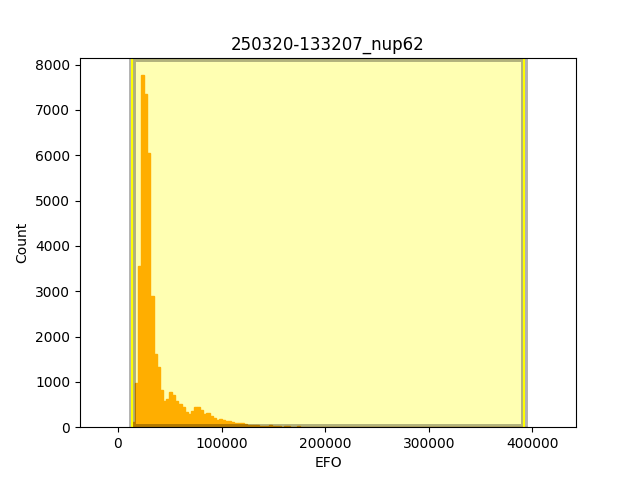

/Users/maximiliansenftleben/Data/8376_alm/8376_minflux/data/multicolor/250320-130543_nup96.minflux/250320-130543_nup96.npy


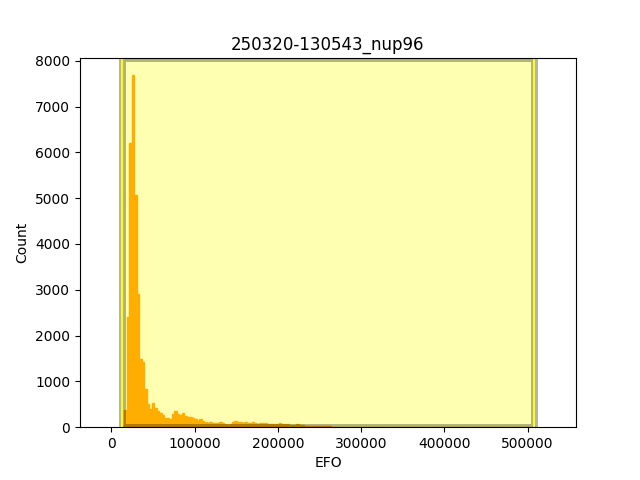

In [19]:
min_trace_length = 3
z_correction_factor = 0.7
scale_factor = 1000000000
save_folder = data_path + "_filtered"
os.makedirs(save_folder, exist_ok=True)

to_save = {}

# find all npy files in the data_path and its subfolders
npy_files = glob.glob(os.path.join(data_path, "**", "*.npy"), recursive=True)
for file in npy_files:
    print(file)
    try:
        MFX_Data = np.load(file)

        # keep valid localizations only (vld field)
        MFX_Data =  MFX_Data[MFX_Data['vld'] == True]
        
        # z correction
        MFX_Data['loc'][:,-1] = MFX_Data['loc'][:,-1]*z_correction_factor
        MFX_Data['loc'] = MFX_Data['loc']*scale_factor

        # take last iteration only
        MFX_Data_vld_fnl =  MFX_Data[(MFX_Data['itr'] == max(MFX_Data['itr'])) & (MFX_Data['itr'] == max(MFX_Data['itr']))]

        # trace filtering
        unique_tids, inv_idx, locs_per_tid = np.unique(MFX_Data_vld_fnl['tid'],  return_inverse=True,return_counts=True) 
        MFX_Data_vld_fnl_filt = MFX_Data_vld_fnl[locs_per_tid[inv_idx]>=min_trace_length] 

        # efo thresholding
        save_path = os.path.join(save_folder, f'{os.path.splitext(os.path.basename(file))[0]}.csv')
        fig, ax, span = efo_filtering_box(MFX_Data_vld_fnl_filt, save_path, to_save)
        xmin, xmax = span.extents

        # TODO might want to make this later to gain speed
        MFX_data_filtered = MFX_Data_vld_fnl_filt[(MFX_Data_vld_fnl_filt['efo'] >= xmin) & (MFX_Data_vld_fnl_filt['efo'] <= xmax)]
        df = np_to_df(MFX_data_filtered)
    
        to_save[save_path] = df
        plt.show()

    except FileNotFoundError:
        print(f"No .npy files found in {data_path}.")
        continue

### Do median calculation (using the LOC values)

In the exported data there are two types of localization coordinates: the MINFLUX Beamline Monitoring (MBM) corrected, called LOC, and the raw localizations, named LNC which stands for Localizations not corrected. Both fields have three columns, one for each 3D cartesian coordinate: x, y, and z.

In [20]:
dims = ['x', 'y', 'z']
for save_path, df in to_save.items():
    save_to_csv(df, save_path)      # save filtered data
    index = os.path.basename(save_path).split('.')[0]
    avg_df = pd.DataFrame()
    for dim in dims:
        avg_df[f'loc_{dim}_mean'] = df.groupby('tid')[f'loc_{dim}'].median()      # TODO median or mean?
        avg_df[f'loc_{dim}_std'] = df.groupby('tid')[f'loc_{dim}'].std()          # std
    
    avg_df['n'] = df.groupby('tid')[f'loc_{dims[0]}'].count()
    avg_df['tim_tot'] = df.groupby('tid')[f'tim'].sum()

    # save as csv
    avg_save_path = os.path.join(save_folder, f'{index}_stats.csv')
    print(f"Saving stats to {avg_save_path}")
    avg_df.to_csv(avg_save_path)

Saved to /Users/maximiliansenftleben/Data/8376_alm/8376_minflux/data/multicolor_filtered/250320-133207_nup62.csv
Saving stats to /Users/maximiliansenftleben/Data/8376_alm/8376_minflux/data/multicolor_filtered/250320-133207_nup62_stats.csv
Saved to /Users/maximiliansenftleben/Data/8376_alm/8376_minflux/data/multicolor_filtered/250320-130543_nup96.csv
Saving stats to /Users/maximiliansenftleben/Data/8376_alm/8376_minflux/data/multicolor_filtered/250320-130543_nup96_stats.csv
